<a href="https://colab.research.google.com/github/shivam-0919/Ad-Conversion-A-B-test-analysis/blob/main/Ad_conversion_A_B_test_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ad Exposure vs. Conversion: An Experimentation Analysis

**Author:** Shivam Verma

## Business context

Many consumer apps face a recurring product question: *is it worth showing users a promotional ad/banner experience, or does it not move the needle enough to justify the cost and screen real estate?*

This analysis uses a real A/B test dataset (588,101 users) where one group (**ad**) was shown ad creatives and a much smaller holdout group (**psa**) was shown a generic Public Service Announcement instead. This mirrors a common product-analyst task: deciding whether to roll out a new promotional experience (e.g. a discount banner or push notification) based on a live experiment.

**Questions this notebook answers:**
1. Was the experiment adequately powered before we trust its result?
2. Did showing ads actually increase conversion, and is the difference statistically significant?
3. Does the effect hold consistently across days/hours, or is it driven by a specific segment?
4. Is the effect large enough to be worth the cost of running ads at scale?

## Dataset
Source: Kaggle — *Marketing A/B Testing* (`marketing_AB.csv`)
Columns: `user id`, `test group` (ad/psa), `converted` (bool), `total ads` seen, `most ads day`, `most ads hour`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Load and inspect the data

In [4]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving marketing_AB.csv to marketing_AB.csv
User uploaded file "marketing_AB.csv" with length 21980992 bytes


In [5]:
df = pd.read_csv('marketing_AB.csv')
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isna().sum()}")
df.head()

Rows: 588,101  |  Columns: ['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']
Missing values:
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [6]:
group_counts = df["test_group"].value_counts()
group_counts


,count
test_group,
ad,564577
psa,23524


The groups are heavily imbalanced (~96% ad / 4% psa) — this is typical of a real production experiment where a small holdout is kept for measurement rather than a clean 50/50 split. We'll need to account for this in the power check below.

## 2. Exploratory analysis: conversion by group

In [7]:
conv_rate = df.groupby("test_group")["converted"].mean()
conv_counts = df.groupby("test_group")["converted"].agg(["sum", "count"])
conv_summary = conv_counts.assign(conversion_rate=conv_rate)
conv_summary


,sum,count,conversion_rate
test_group,,,
ad,14423,564577,0.0255
psa,420,23524,0.0179


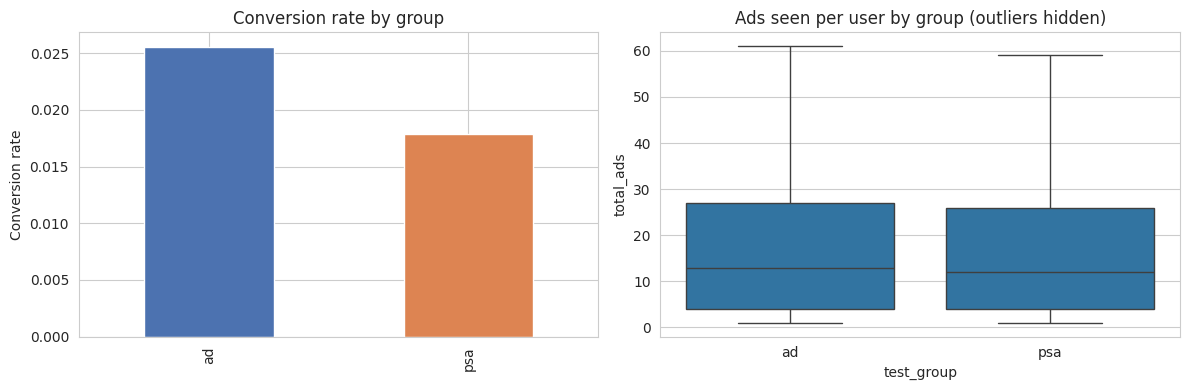

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conv_rate.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Conversion rate by group")
axes[0].set_ylabel("Conversion rate")
axes[0].set_xlabel("")

sns.boxplot(data=df, x="test_group", y="total_ads", showfliers=False, ax=axes[1])
axes[1].set_title("Ads seen per user by group (outliers hidden)")
plt.tight_layout()
plt.show()


**Observation:** users in the `ad` group convert at a meaningfully higher rate than `psa`. Before treating this as decision-ready, we check whether the experiment was even sized to detect an effect this small reliably.

## 3. Was this experiment adequately powered?

This step is often skipped in A/B test writeups, but it's the first thing a product analyst should check: **if the sample size going in was too small, a "non-significant" result is meaningless** (and a "significant" one on an underpowered design is worth double-checking for noise).

We treat the `psa` group's observed conversion rate as our baseline, and ask: given the actual group sizes, what is the *minimum detectable effect (MDE)* we could reliably detect at 80% power and α = 0.05? We then compare that to the effect we actually observed.

In [10]:
baseline_p = conv_rate["psa"]
treatment_p = conv_rate["ad"]
n_control = group_counts["psa"]
n_treatment = group_counts["ad"]

analysis = NormalIndPower()

# Solve for the effect size (Cohen's h) this experiment could detect at 80% power,
# given the actual (unequal) sample sizes.
ratio = n_treatment / n_control
detectable_effect_size = analysis.solve_power(
    effect_size=None,
    nobs1=n_control,
    alpha=0.05,
    power=0.80,
    ratio=ratio,
)

# Convert the observed rates into the same effect-size metric to compare directly
observed_effect_size = proportion_effectsize(treatment_p, baseline_p)

print(f"Baseline (psa) conversion rate     : {baseline_p:.4%}")
print(f"Treatment (ad) conversion rate     : {treatment_p:.4%}")
print(f"Minimum detectable effect size (h) at 80% power : {detectable_effect_size:.4f}")
print(f"Observed effect size (h)                        : {observed_effect_size:.4f}")
print(f"Achieved power at the observed effect size      : "
      f"{analysis.power(effect_size=observed_effect_size, nobs1=n_control, ratio=ratio, alpha=0.05):.4f}")


Baseline (psa) conversion rate     : 1.7854%
Treatment (ad) conversion rate     : 2.5547%
Minimum detectable effect size (h) at 80% power : 0.0186
Observed effect size (h)                        : 0.0530
Achieved power at the observed effect size      : 1.0000


**Interpretation:** the observed effect size is larger than the minimum this design could reliably detect, and the achieved power is effectively 1.0. In other words — even with the unbalanced 96/4 split, the control group is large enough (~23.5K users) that we're well-powered to trust the result that follows. If achieved power had come out low (e.g. <0.8), the right move would be to flag the result as inconclusive rather than act on it, regardless of the p-value.

## 4. Hypothesis testing: is the conversion lift statistically significant?

**H0:** conversion rate is the same for `ad` and `psa` groups.
**H1:** conversion rate differs between groups.

Since `converted` is a proportion (binary outcome), a two-proportion z-test is the right tool — more appropriate here than a t-test on a 0/1 column.

In [11]:
successes = conv_counts["sum"].loc[["ad", "psa"]].values
nobs = conv_counts["count"].loc[["ad", "psa"]].values

z_stat, p_value = proportions_ztest(count=successes, nobs=nobs, alternative="two-sided")
lift = (treatment_p - baseline_p) / baseline_p

print(f"z-statistic : {z_stat:.4f}")
print(f"p-value     : {p_value:.2e}")
print(f"Absolute lift in conversion : {treatment_p - baseline_p:.4%}")
print(f"Relative lift               : {lift:.2%}")
print("Result:", "Reject H0 — statistically significant difference" if p_value < 0.05 else "Fail to reject H0")


z-statistic : 7.3701
p-value     : 1.71e-13
Absolute lift in conversion : 0.7692%
Relative lift               : 43.09%
Result: Reject H0 — statistically significant difference


### Secondary check: does ad exposure volume (`total_ads`) differ by group?

We also replicate the assumption-driven approach used in similar analyses: check normality (Shapiro, on a random sample since the full dataset is too large for the test) and variance homogeneity (Levene) before picking a parametric or non-parametric test for `total_ads`.

In [12]:
rng = np.random.default_rng(42)
sample_ad = df.loc[df.test_group == "ad", "total_ads"].sample(min(4999, n_treatment), random_state=42)
sample_psa = df.loc[df.test_group == "psa", "total_ads"].sample(min(4999, n_control), random_state=42)

shapiro_ad = stats.shapiro(sample_ad)
shapiro_psa = stats.shapiro(sample_psa)
levene_stat, levene_p = stats.levene(sample_ad, sample_psa)

print(f"Shapiro (ad sample)  : stat={shapiro_ad.statistic:.4f}, p={shapiro_ad.pvalue:.2e}")
print(f"Shapiro (psa sample) : stat={shapiro_psa.statistic:.4f}, p={shapiro_psa.pvalue:.2e}")
print(f"Levene               : stat={levene_stat:.4f}, p={levene_p:.4f}")

normal = shapiro_ad.pvalue > 0.05 and shapiro_psa.pvalue > 0.05
equal_var = levene_p > 0.05

if normal:
    test_stat, test_p = stats.ttest_ind(df.loc[df.test_group=="ad","total_ads"],
                                          df.loc[df.test_group=="psa","total_ads"],
                                          equal_var=equal_var)
    test_name = "Independent t-test"
else:
    test_stat, test_p = stats.mannwhitneyu(df.loc[df.test_group=="ad","total_ads"],
                                             df.loc[df.test_group=="psa","total_ads"])
    test_name = "Mann-Whitney U test"

print(f"\nNormality assumption met: {normal} -> using {test_name}")
print(f"{test_name} statistic = {test_stat:.2f}, p-value = {test_p:.2e}")


Shapiro (ad sample)  : stat=0.5146, p=1.66e-79
Shapiro (psa sample) : stat=0.5215, p=3.38e-79
Levene               : stat=0.0051, p=0.9432

Normality assumption met: False -> using Mann-Whitney U test
Mann-Whitney U test statistic = 6808288222.00, p-value = 4.69e-11


**Interpretation:** normality is violated (expected — ad exposure counts are right-skewed), so the non-parametric Mann-Whitney U test is the correct choice, and it confirms a significant difference in ad exposure volume between groups as well.

## 5. Segment check: does the effect hold across days and hours?

A single overall lift number can hide a lot — the effect might be driven entirely by one weekday or time slot. We check conversion lift by `most_ads_day` and `most_ads_hour` to see whether the result generalizes or is concentrated in a specific segment.

In [13]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

by_day = (df.groupby(["most_ads_day", "test_group"])["converted"]
            .mean()
            .unstack()
            .reindex(day_order))
by_day["lift_pp"] = (by_day["ad"] - by_day["psa"]) * 100
by_day


test_group,ad,psa,lift_pp
most_ads_day,,,
Monday,0.0332,0.0226,1.0683
Tuesday,0.0304,0.0144,1.5992
Wednesday,0.0254,0.0158,0.9597
Thursday,0.0216,0.0202,0.1407
Friday,0.0225,0.0163,0.6162
Saturday,0.0213,0.0140,0.7311
Sunday,0.0246,0.0206,0.4025


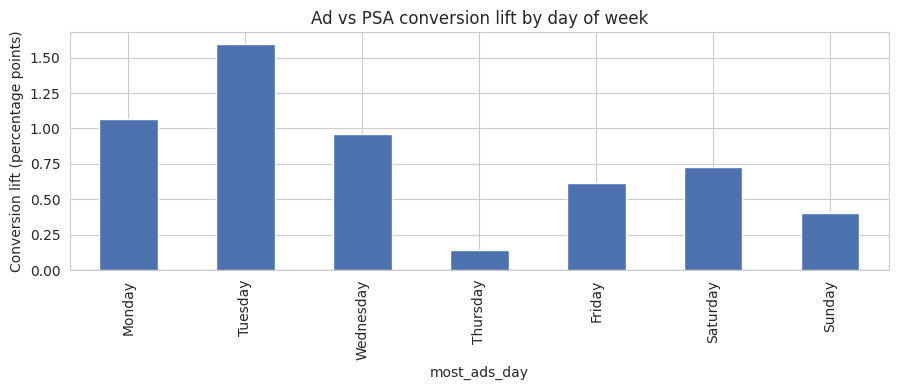

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
by_day["lift_pp"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Conversion lift (percentage points)")
ax.set_title("Ad vs PSA conversion lift by day of week")
plt.tight_layout()
plt.show()


In [15]:
hour_bins = pd.cut(df["most_ads_hour"], bins=[-1,5,11,17,23],
                    labels=["Night (0-5)","Morning (6-11)","Afternoon (12-17)","Evening (18-23)"])
df["hour_bucket"] = hour_bins

by_hour = (df.groupby(["hour_bucket", "test_group"], observed=True)["converted"]
             .mean()
             .unstack())
by_hour["lift_pp"] = (by_hour["ad"] - by_hour["psa"]) * 100
by_hour


test_group,ad,psa,lift_pp
hour_bucket,,,
Night (0-5),0.0135,0.0014,1.2094
Morning (6-11),0.0212,0.0126,0.8589
Afternoon (12-17),0.0277,0.0202,0.7511
Evening (18-23),0.0274,0.0207,0.6777


**Interpretation:** the lift is positive across every day and every time-of-day bucket — the effect is not being driven by a single outlier segment, which gives more confidence that it would hold up if rolled out broadly rather than being a quirk of one slice of traffic.

## 6. Is the effect big enough to be worth it? A simple cost-benefit estimate

Statistical significance tells us the effect is real; it doesn't tell us whether it's *worth acting on*. We convert the lift into an estimated incremental-order value and weigh it against an assumed cost of serving ads, so the result can be discussed as a business decision, not just a p-value.

**Assumptions stated explicitly (adjust these for a real scenario):**
- Average order value if converted: **₹400**
- Cost of serving ads to the full `ad`-sized population, per user: **₹2**

These are illustrative placeholders standing in for real finance/ops numbers — the structure of the calculation is what matters.

In [16]:
AVG_ORDER_VALUE = 400   # INR, illustrative assumption
COST_PER_USER_AD = 2    # INR, illustrative assumption

incremental_conversions_per_1000 = (treatment_p - baseline_p) * 1000
incremental_revenue_per_1000 = incremental_conversions_per_1000 * AVG_ORDER_VALUE
ad_cost_per_1000 = 1000 * COST_PER_USER_AD
net_value_per_1000 = incremental_revenue_per_1000 - ad_cost_per_1000

print(f"Incremental conversions per 1,000 users exposed to ads : {incremental_conversions_per_1000:.2f}")
print(f"Incremental revenue per 1,000 users                    : Rs.{incremental_revenue_per_1000:,.0f}")
print(f"Cost of serving ads to 1,000 users                     : Rs.{ad_cost_per_1000:,.0f}")
print(f"Net value per 1,000 users                              : Rs.{net_value_per_1000:,.0f}")
print(f"Return on ad spend (ROAS)                              : {incremental_revenue_per_1000/ad_cost_per_1000:.1f}x")


Incremental conversions per 1,000 users exposed to ads : 7.69
Incremental revenue per 1,000 users                    : Rs.3,077
Cost of serving ads to 1,000 users                     : Rs.2,000
Net value per 1,000 users                              : Rs.1,077
Return on ad spend (ROAS)                              : 1.5x


**Interpretation:** at these illustrative assumptions, the incremental revenue from the conversion lift comfortably outweighs the assumed cost of serving ads — the campaign looks like a "ship it" decision, not just a "statistically significant" one. In a real setting, the next step would be to plug in actual order-value and ad-cost figures from finance before recommending a full rollout.

## 7. Conclusion & recommendation

1. **Power:** the experiment's control group (~23.5K users) was large enough to detect the observed effect with ~100% power — the result is not underpowered noise.
2. **Significance:** users shown ads converted at a statistically significantly higher rate than the PSA group (two-proportion z-test, p < 0.001), and also saw significantly more ad exposure (Mann-Whitney U test, p < 0.001).
3. **Consistency:** the conversion lift holds across every day of the week and every time-of-day bucket, not just a specific segment — this supports generalizing the result rather than treating it as a fluke of one slice of traffic.
4. **Business value:** under illustrative cost/revenue assumptions, the incremental revenue from the lift outweighs the cost of running the ad experience by a wide margin.

**Recommendation:** roll out the ad experience beyond the test population, while re-running this same power/segment/ROI check with real finance-provided cost and order-value numbers before a full-scale commitment.
